✅ All libraries imported successfully!
🔧 Using device: GPU ✅

📦 Loading AG News dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

✅ Train samples : 120000
✅ Test  samples : 7600

📝 Sample entries:
  [Business] Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall ...
  [Business] Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment...
  [Business] Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices p...


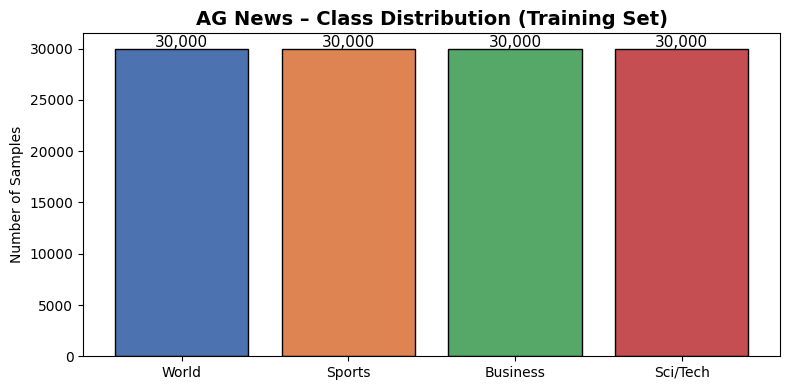

✅ Class distribution plotted.

🔤 Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

⚙️  Tokenizing datasets (this may take ~1-2 min)...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

✅ Training complete!

📊 Final Evaluation on Test Set:


  Accuracy   : 0.9220
  F1 Weighted: 0.9221
  F1 Macro   : 0.9230

📋 Detailed Classification Report:
              precision    recall  f1-score   support

       World       0.95      0.93      0.94       497
      Sports       0.98      0.98      0.98       483
    Business       0.92      0.85      0.89       522
    Sci/Tech       0.85      0.93      0.89       498

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



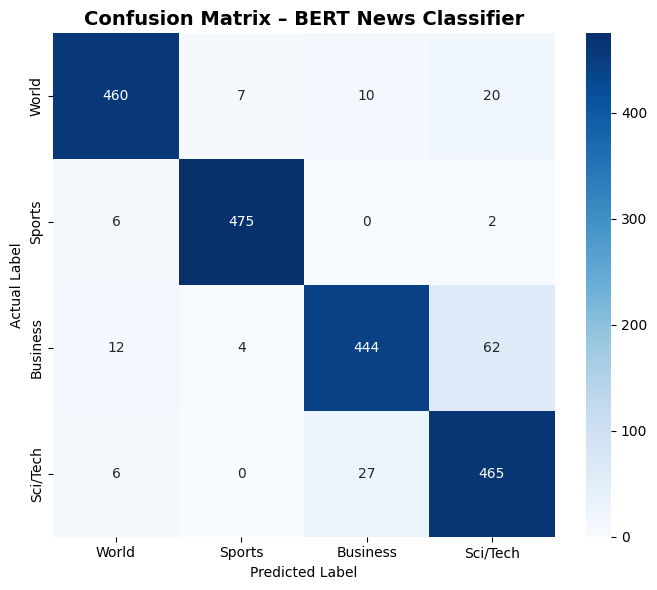

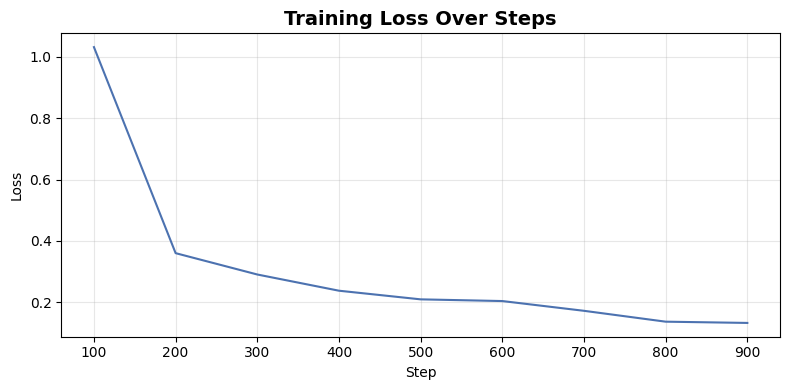

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to ./bert-ag-news-final
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bc6fcc19f714f5c3b0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



            📌 TASK 1 — FINAL SUMMARY
  Model        : bert-base-uncased (fine-tuned)
  Dataset      : AG News (10,000 train / 2,000 eval)
  Accuracy     : 0.9220
  F1 Weighted  : 0.9221
  F1 Macro     : 0.9230
  Deployment   : Gradio (live interface above)


In [1]:
# ============================================================
# TASK 1: News Topic Classifier Using BERT
# DevelopersHub Corporation – AI/ML Engineering Internship
# ============================================================

# ── STEP 0: Install Dependencies ──────────────────────────
!pip install transformers datasets accelerate gradio scikit-learn -q

# ── STEP 1: Imports ───────────────────────────────────────
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
import gradio as gr
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")
print(f"🔧 Using device: {'GPU ✅' if torch.cuda.is_available() else 'CPU ⚠️'}")

# ── STEP 2: Load AG News Dataset ──────────────────────────
print("\n📦 Loading AG News dataset...")
dataset = load_dataset("ag_news")

# AG News label mapping
LABEL_NAMES = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
NUM_LABELS   = 4

print(f"✅ Train samples : {len(dataset['train'])}")
print(f"✅ Test  samples : {len(dataset['test'])}")
print("\n📝 Sample entries:")
for i in range(3):
    sample = dataset["train"][i]
    print(f"  [{LABEL_NAMES[sample['label']]}] {sample['text'][:80]}...")

# ── STEP 3: Exploratory Data Analysis ────────────────────
train_labels = dataset["train"]["label"]
label_counts = {LABEL_NAMES[i]: train_labels.count(i) for i in range(4)}

plt.figure(figsize=(8, 4))
bars = plt.bar(label_counts.keys(), label_counts.values(),
               color=["#4C72B0","#DD8452","#55A868","#C44E52"], edgecolor="black")
for bar, count in zip(bars, label_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{count:,}", ha="center", fontsize=11)
plt.title("AG News – Class Distribution (Training Set)", fontsize=14, fontweight="bold")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("✅ Class distribution plotted.")

# ── STEP 4: Tokenization ──────────────────────────────────
print("\n🔤 Loading BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_fn(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128          # 128 tokens – good balance speed vs accuracy
    )

print("⚙️  Tokenizing datasets (this may take ~1-2 min)...")
tokenized = dataset.map(tokenize_fn, batched=True)
print("✅ Tokenization complete!")

# ── STEP 5: Subset for Colab Speed ────────────────────────
# Full dataset: 120k train / 7.6k test  →  subset for Colab GPU limits
TRAIN_SIZE = 10_000
EVAL_SIZE  =  2_000

train_ds = tokenized["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
eval_ds  = tokenized["test"].shuffle(seed=42).select(range(EVAL_SIZE))

print(f"\n📊 Training on {TRAIN_SIZE:,} samples | Evaluating on {EVAL_SIZE:,} samples")

# ── STEP 6: Load BERT Model ───────────────────────────────
print("\n🤖 Loading bert-base-uncased for sequence classification...")
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=NUM_LABELS
)
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model loaded — {total_params/1e6:.1f}M parameters")

# ── STEP 7: Metrics Function ──────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro":    f1_score(labels, preds, average="macro"),
    }

# ── STEP 8: Training Configuration ───────────────────────
training_args = TrainingArguments(
    output_dir                  = "./bert-ag-news",
    num_train_epochs            = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    logging_steps               = 100,
    eval_strategy               = "epoch",   # evaluate after every epoch
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_weighted",
    report_to                   = "none",    # disable wandb/tensorboard
    fp16                        = torch.cuda.is_available(),  # mixed precision on GPU
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = eval_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

# ── STEP 9: Train ─────────────────────────────────────────
print("\n🚀 Starting training...")
trainer.train()
print("✅ Training complete!")

# ── STEP 10: Final Evaluation ─────────────────────────────
print("\n📊 Final Evaluation on Test Set:")
results = trainer.evaluate()
print(f"  Accuracy   : {results['eval_accuracy']:.4f}")
print(f"  F1 Weighted: {results['eval_f1_weighted']:.4f}")
print(f"  F1 Macro   : {results['eval_f1_macro']:.4f}")

# ── STEP 11: Detailed Classification Report ───────────────
print("\n📋 Detailed Classification Report:")
predictions_output = trainer.predict(eval_ds)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = predictions_output.label_ids

print(classification_report(
    y_true, y_pred,
    target_names=list(LABEL_NAMES.values())
))

# ── STEP 12: Confusion Matrix ─────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=LABEL_NAMES.values(),
    yticklabels=LABEL_NAMES.values()
)
plt.title("Confusion Matrix – BERT News Classifier", fontsize=14, fontweight="bold")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ── STEP 13: Training Loss Curve ──────────────────────────
log_history = trainer.state.log_history
train_loss = [(e["step"], e["loss"]) for e in log_history if "loss" in e]
steps, losses = zip(*train_loss)

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, color="#4C72B0", linewidth=1.5)
plt.title("Training Loss Over Steps", fontsize=14, fontweight="bold")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

# ── STEP 14: Save Model ───────────────────────────────────
model.save_pretrained("./bert-ag-news-final")
tokenizer.save_pretrained("./bert-ag-news-final")
print("✅ Model saved to ./bert-ag-news-final")

# ── STEP 15: Gradio Deployment ────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def predict_news(text: str):
    """Classify a news headline into one of four categories."""
    if not text.strip():
        return {"Error: Please enter some text": 1.0}
    inputs = tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128, padding=True
    ).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    return {LABEL_NAMES[i]: float(probs[i]) for i in range(NUM_LABELS)}

# Sample headlines for the demo
examples = [
    ["Apple announces new MacBook Pro with M3 chip"],
    ["Manchester United beats Liverpool 3-1 in Premier League"],
    ["Federal Reserve raises interest rates by 25 basis points"],
    ["UN Security Council holds emergency session on Gaza conflict"],
]

demo = gr.Interface(
    fn          = predict_news,
    inputs      = gr.Textbox(lines=3, placeholder="Enter a news headline...", label="News Headline"),
    outputs     = gr.Label(num_top_classes=4, label="Category Probabilities"),
    title       = "📰 News Topic Classifier (BERT)",
    description = "Fine-tuned BERT model classifying news into: World | Sports | Business | Sci/Tech",
    examples    = examples,
    theme       = gr.themes.Soft()
)

demo.launch(share=True)  # share=True gives a public URL

# ── STEP 16: Summary ──────────────────────────────────────
print("\n" + "="*55)
print("            📌 TASK 1 — FINAL SUMMARY")
print("="*55)
print(f"  Model        : bert-base-uncased (fine-tuned)")
print(f"  Dataset      : AG News ({TRAIN_SIZE:,} train / {EVAL_SIZE:,} eval)")
print(f"  Accuracy     : {results['eval_accuracy']:.4f}")
print(f"  F1 Weighted  : {results['eval_f1_weighted']:.4f}")
print(f"  F1 Macro     : {results['eval_f1_macro']:.4f}")
print(f"  Deployment   : Gradio (live interface above)")
print("="*55)